In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# Dataset Path
# ----------------------------
DATASET_PATH = "data/train"

classes = ["dark", "normal", "bright"]

results = []

print("Analyzing all training images...\n")

for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    for file in tqdm(os.listdir(folder), desc=cls):

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # ----------------------------
        # RGB -> Gray
        # ----------------------------
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ----------------------------
        # HSV
        # ----------------------------
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        value = hsv[:, :, 2]

        # ----------------------------
        # Statistics
        # ----------------------------

        mean_gray = np.mean(gray)

        std_gray = np.std(gray)

        min_gray = np.min(gray)

        max_gray = np.max(gray)

        median_gray = np.median(gray)

        mean_value = np.mean(value)

        std_value = np.std(value)

        # Percentage of dark pixels

        dark_ratio = np.mean(gray < 50)

        # Percentage of bright pixels

        bright_ratio = np.mean(gray > 200)

        results.append({

            "class": cls,

            "mean_gray": mean_gray,

            "median_gray": median_gray,

            "std_gray": std_gray,

            "min_gray": min_gray,

            "max_gray": max_gray,

            "mean_value": mean_value,

            "std_value": std_value,

            "dark_ratio": dark_ratio,

            "bright_ratio": bright_ratio

        })

# ----------------------------
# DataFrame
# ----------------------------

df = pd.DataFrame(results)

print("\nAnalysis Complete!\n")

summary = df.groupby("class").agg({

    "mean_gray": ["mean", "std"],

    "median_gray": ["mean"],

    "std_gray": ["mean"],

    "mean_value": ["mean"],

    "std_value": ["mean"],

    "dark_ratio": ["mean"],

    "bright_ratio": ["mean"]

})

display(summary)

Analyzing all training images...



bright: 100%|██████████| 500/500 [00:05<00:00, 91.97it/s]


Analysis Complete!



mean_gray            median_gray   std_gray mean_value  std_value  \
             mean        std        mean       mean       mean       mean   
class                                                                       
bright  80.278295  18.939502      78.626  42.254326  87.160791  42.815635   
dark    64.031197  18.317973      58.291  39.622865  70.297366  40.565973   
normal  81.569505  18.658174      80.640  41.293134  88.478030  41.777970   

       dark_ratio bright_ratio  
             mean         mean  
class                           
bright   0.299378     0.007205  
dark     0.453221     0.004512  
normal   0.281156     0.009035

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

### cell 2 - Boxplot - Mean Gray Intensity

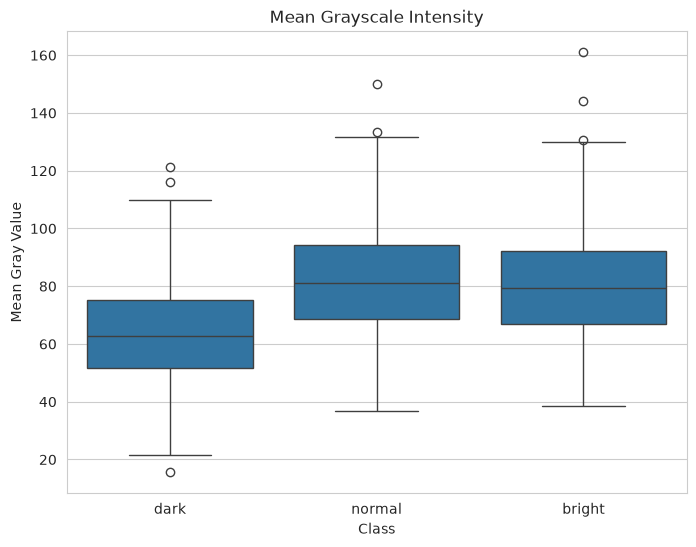

In [3]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="mean_gray"
)

plt.title("Mean Grayscale Intensity")
plt.xlabel("Class")
plt.ylabel("Mean Gray Value")

plt.show()

### Cell 3: Boxplot - HSV Value

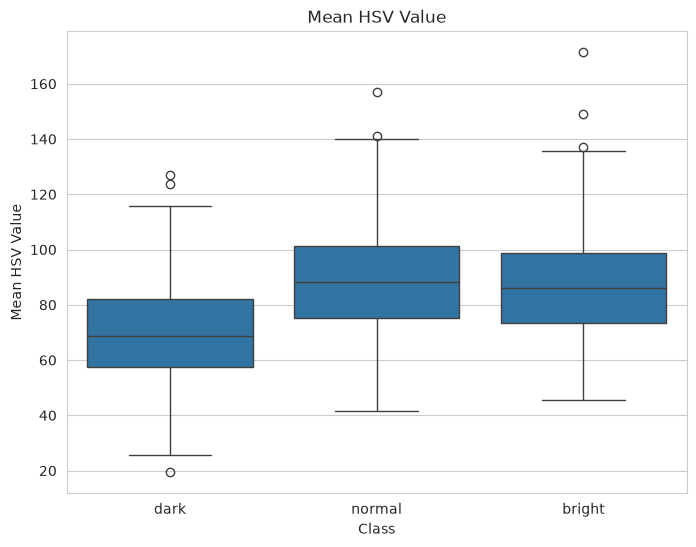

In [4]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="mean_value"
)

plt.title("Mean HSV Value")
plt.xlabel("Class")
plt.ylabel("Mean HSV Value")

plt.show()

### Cell 4: Boxplot - Dark Pixel Ratio

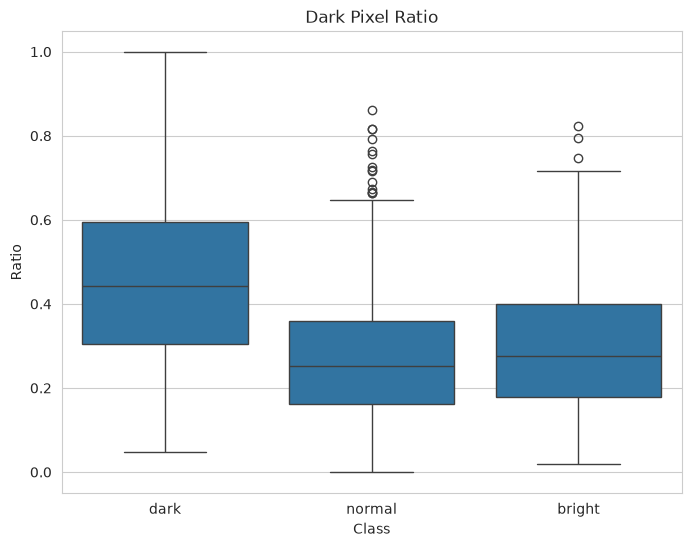

In [5]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="dark_ratio"
)

plt.title("Dark Pixel Ratio")
plt.xlabel("Class")
plt.ylabel("Ratio")

plt.show()

### Cell 5: Boxplot - Bright Pixel Ratio

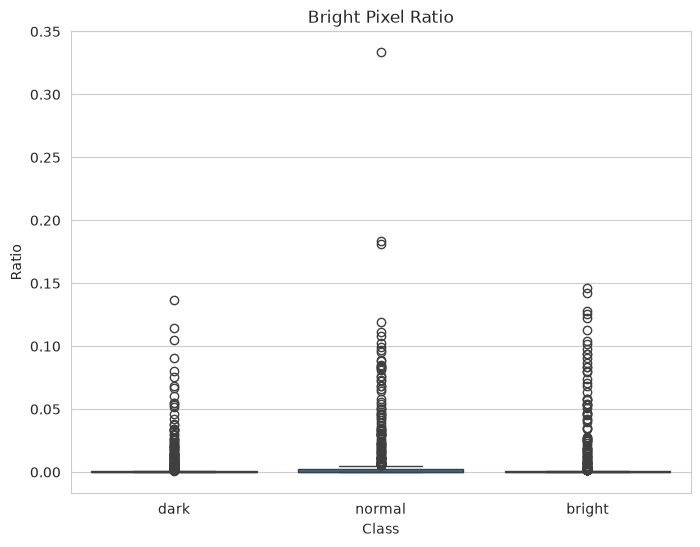

In [6]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="class",
    y="bright_ratio"
)

plt.title("Bright Pixel Ratio")
plt.xlabel("Class")
plt.ylabel("Ratio")

plt.show()

### Cell 6: Histogram - Mean Gray

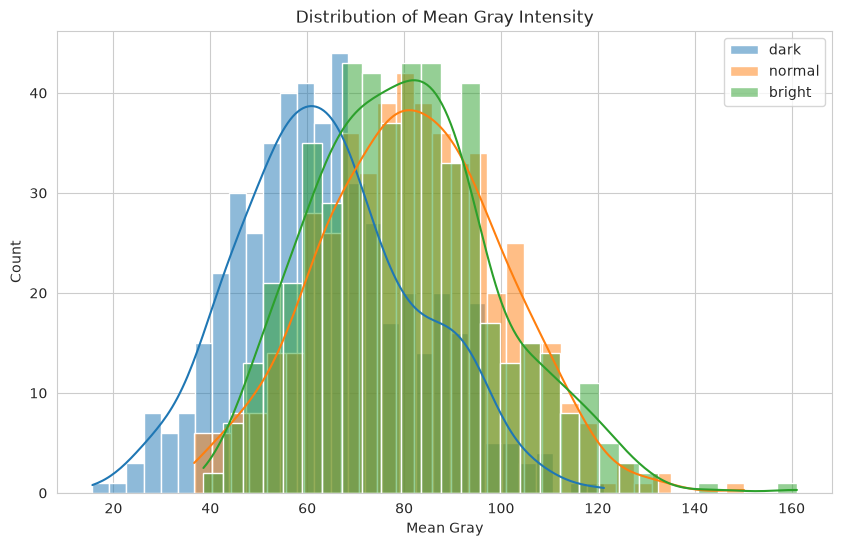

In [7]:
plt.figure(figsize=(10,6))

for cls in ["dark", "normal", "bright"]:

    sns.histplot(
        df[df["class"] == cls]["mean_gray"],
        bins=30,
        kde=True,
        label=cls,
        alpha=0.5
    )

plt.title("Distribution of Mean Gray Intensity")
plt.xlabel("Mean Gray")
plt.ylabel("Count")

plt.legend()

plt.show()

### Cell 7: Histogram - HSV Value

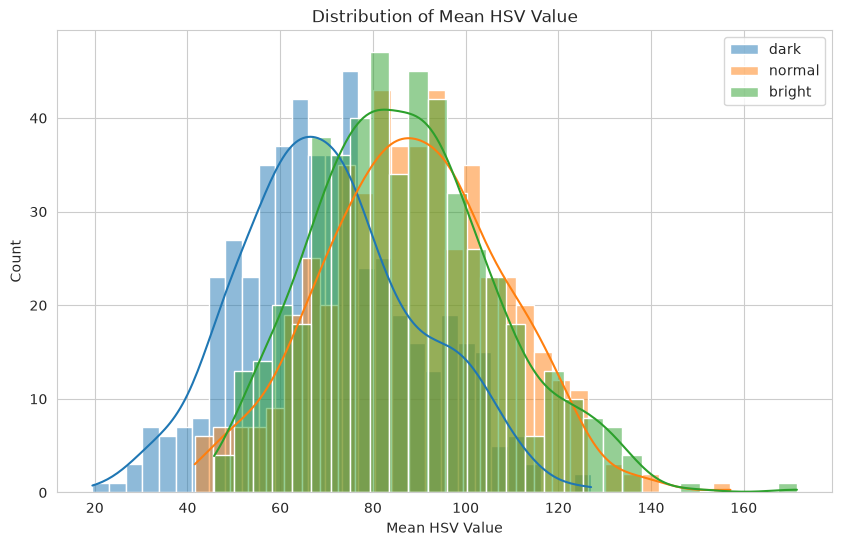

In [8]:
plt.figure(figsize=(10,6))

for cls in ["dark", "normal", "bright"]:

    sns.histplot(
        df[df["class"] == cls]["mean_value"],
        bins=30,
        kde=True,
        label=cls,
        alpha=0.5
    )

plt.title("Distribution of Mean HSV Value")
plt.xlabel("Mean HSV Value")
plt.ylabel("Count")

plt.legend()

plt.show()

### Cell 8: Pairplot

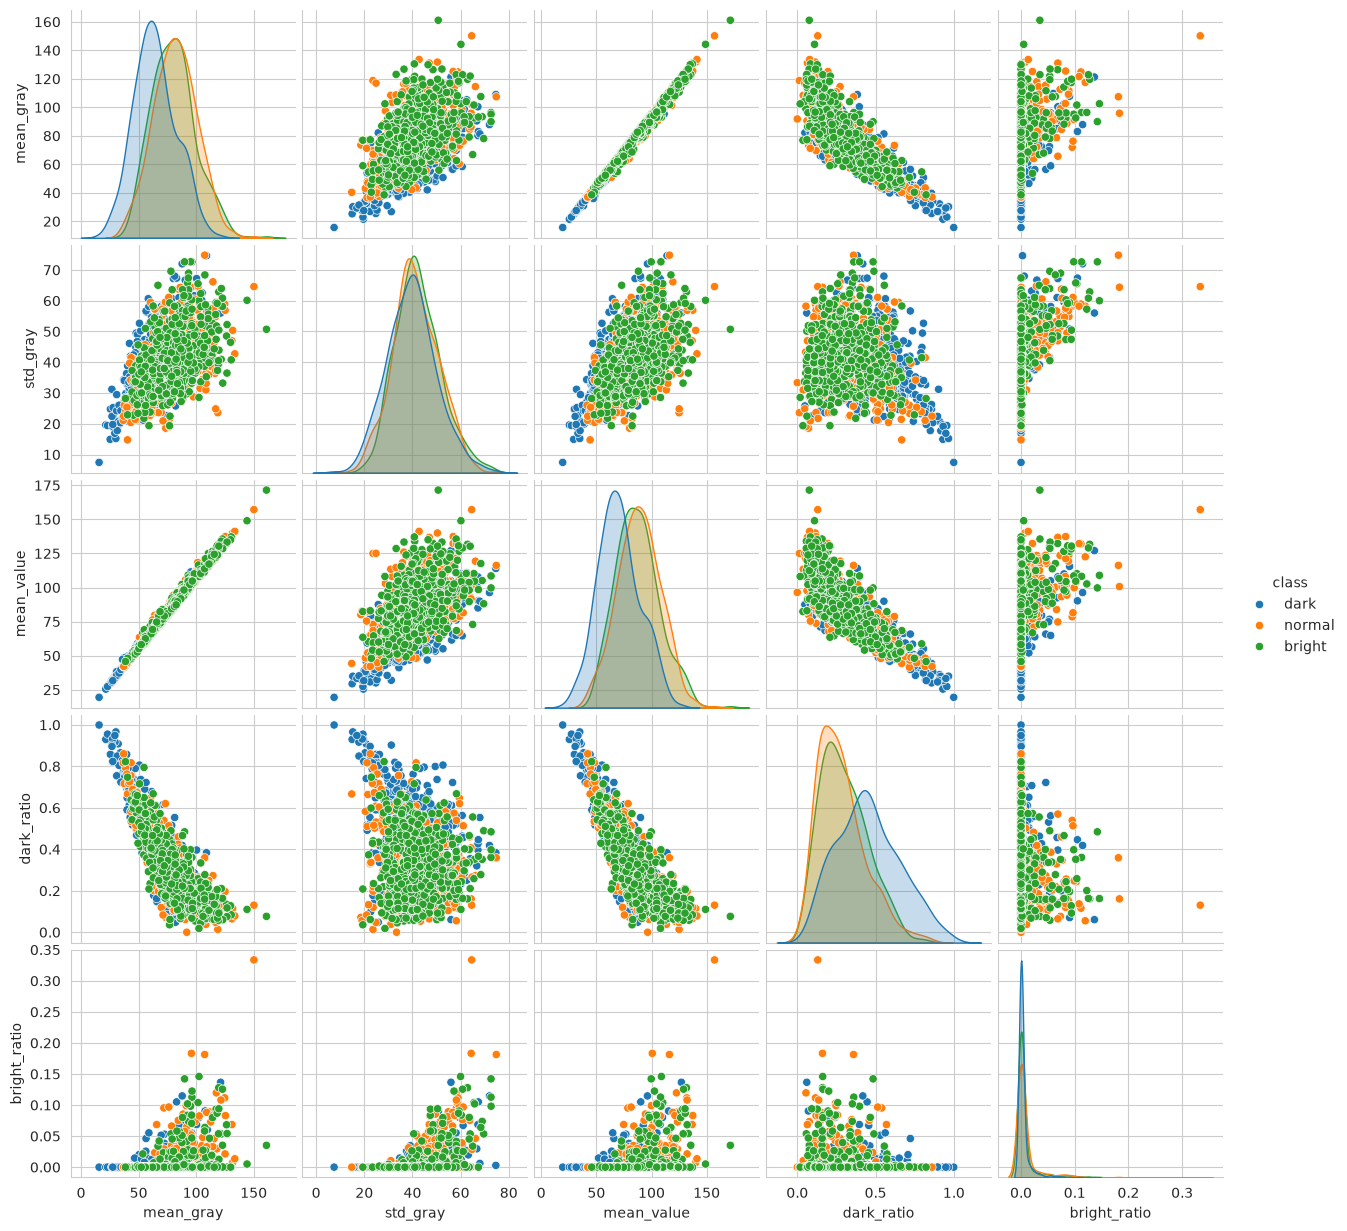

In [9]:
sns.pairplot(
    df,
    hue="class",
    vars=[
        "mean_gray",
        "std_gray",
        "mean_value",
        "dark_ratio",
        "bright_ratio"
    ],
    diag_kind="kde"
)

plt.show()

### Cell 9: Correlation Heatmap

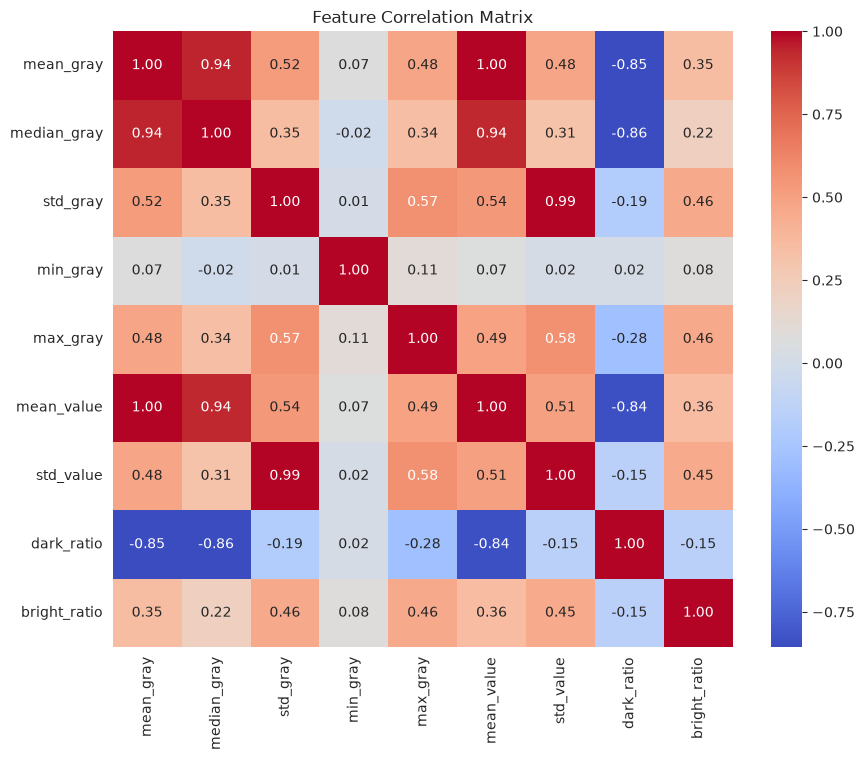

In [10]:
plt.figure(figsize=(10,8))

corr = df.drop(columns=["class"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

### Cell 10: Violin Plot

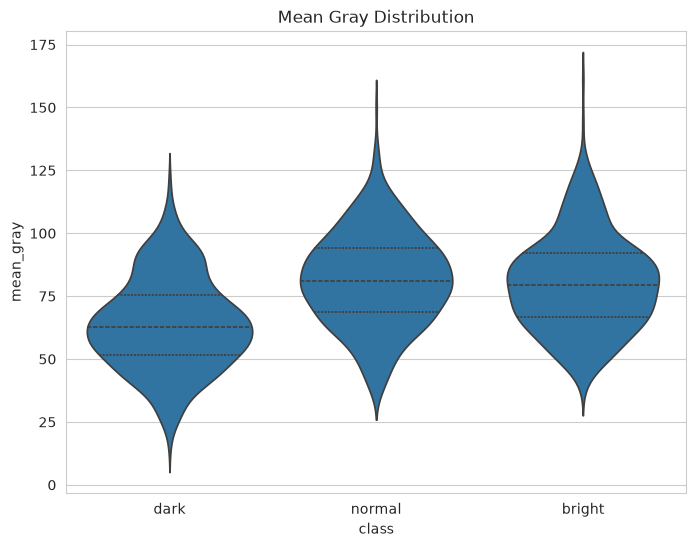

In [11]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="class",
    y="mean_gray",
    inner="quartile"
)

plt.title("Mean Gray Distribution")

plt.show()

### Cell 11: Class-wise Summary Statistics

In [12]:
summary = df.groupby("class").describe()

display(summary)

mean_gray                                                         \
           count       mean        std        min        25%        50%   
class                                                                     
bright     500.0  80.278295  18.939502  38.573395  66.871236  79.342815   
dark       500.0  64.031197  18.317973  15.653549  51.714128  62.824516   
normal     500.0  81.569505  18.658174  36.660919  68.559342  81.172192   

                              median_gray          ... dark_ratio            \
              75%         max       count    mean  ...        75%       max   
class                                              ...                        
bright  92.278393  161.094166       500.0  78.626  ...   0.399180  0.822426   
dark    75.396343  121.257156       500.0  58.291  ...   0.594397  0.999161   
normal  94.262065  150.180183       500.0  80.640  ...   0.358262  0.860172   

       bright_ratio                                                         
              count      mean       std  min  25%  50%       75%       max  
class                                                                       
bright        500.0  0.007205  0.021846  0.0  0.0  0.0  0.000478  0.145969  
dark          500.0  0.004512  0.014446  0.0  0.0  0.0  0.000473  0.136627  
normal        500.0  0.009035  0.027169  0.0  0.0  0.0  0.002109  0.333656  

[3 rows x 72 columns]